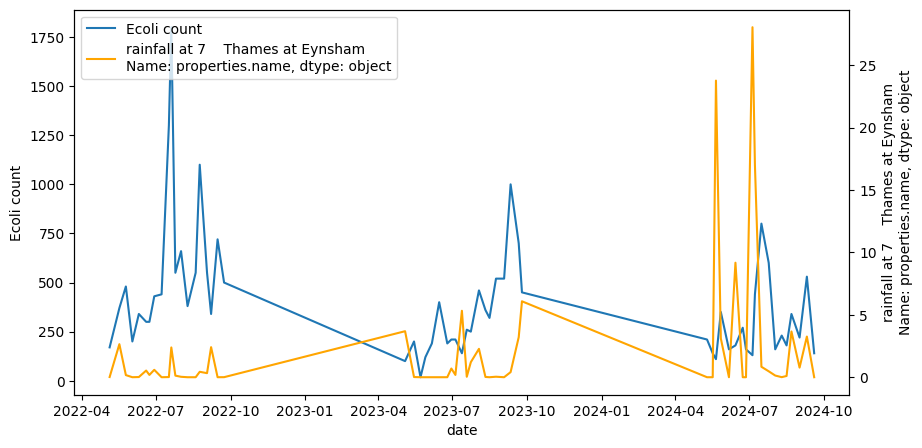

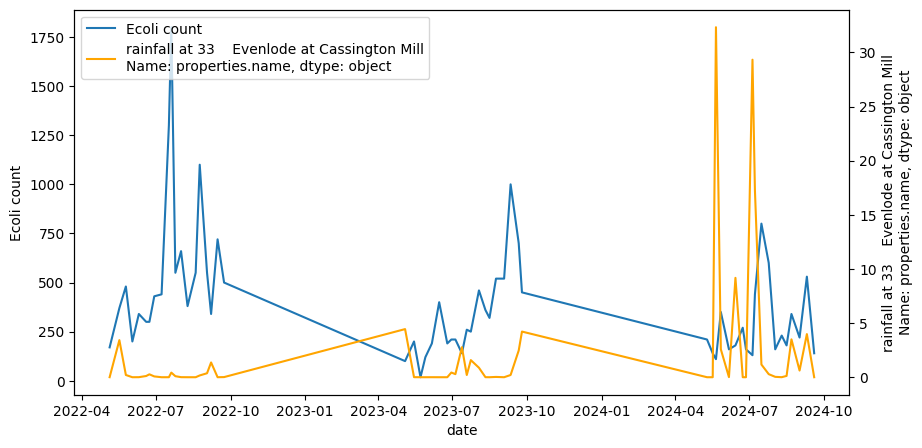

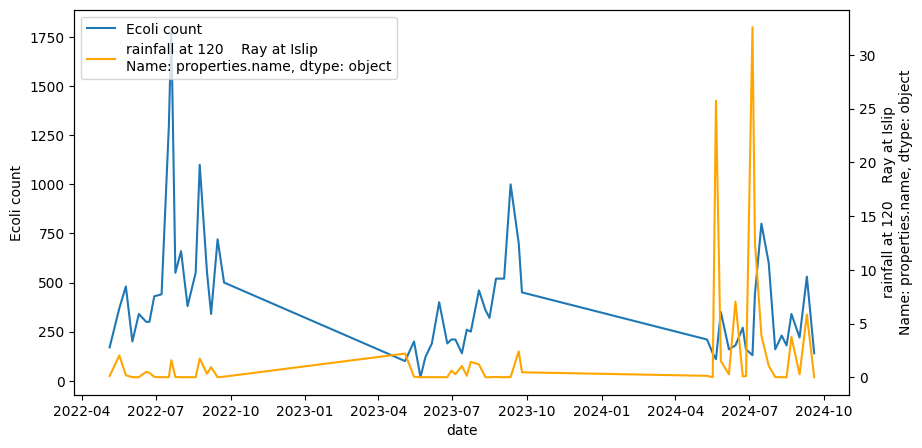

In [79]:
from matplotlib import pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame

import app
import pandas as pd
import geopandas as gpd


ecoli_timeseries_dfs = app.get_ecoli_datasets()
wolvercote_ecoli_timeseries = ecoli_timeseries_dfs[("11946", "ea_bathing_water")]

# get site info for Wolvercote
wolvercote_site_id = "11946"
ecoli_data_set_wolvercote = "ea_bathing_water"
df_ea_bathing_water_site = app.get_sites_for_dataset_as_pandas("ea_bathing_water")
gdf_ea_bathing_water_site = gpd.GeoDataFrame(df_ea_bathing_water_site)
wolvercote_coordinates = gdf_ea_bathing_water_site[gdf_ea_bathing_water_site["properties.id"]==wolvercote_site_id]["geometry.coordinates"]

# get rainfall sites
df_sites_rainfall = app.get_sites_for_dataset_as_pandas("rainfall", display=False)
gdf_sites_rainfall = gpd.GeoDataFrame(df_sites_rainfall)

# find rainfall sites near Wolvercote
from geopy.distance import geodesic
sites_close_to_wolvercote = []
max_distance_km = 8 # 8km
for idx, rainfall_site in gdf_sites_rainfall.iterrows():
    distance_in_km = geodesic(rainfall_site.loc["geometry.coordinates"], wolvercote_coordinates).km
    if distance_in_km < max_distance_km:
            sites_close_to_wolvercote.append(rainfall_site.loc["properties.id"])
# print(sites_close_to_wolvercote) # gives ids ["39008", "39034", "39140"]

# just to experiment, take the rainfall data from "39008", Thames at Eynsham
rainfall_timeseries_rainfall_eynsham = app.get_timeseries_for_dataset_and_site_as_pandas("39008", "rainfall")

# helper functions
def convert_datetime_to_date_with_resampling(df: pd.DataFrame):
    new_df = df.copy()
    new_df["date"] = pd.to_datetime(new_df["datetime"]).dt.date
    new_df["date"] = pd.to_datetime(new_df["date"])
    new_df.set_index('date')
    return new_df

def merge_on_date(df1: pd.DataFrame, df2: pd.DataFrame):
    result = df1.copy()
    result = result.merge(df2, on='date', how='left').dropna()
    return result

def plot_values_vs_date(merged: pd.DataFrame, x: str, y1: str, y2: str, xlabel: str, y1label: str, y2label: str):
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(merged[x], merged[y1], label=y1label)
    ax1.set_ylabel(y1label)
    ax2 = ax1.twinx()
    ax2.plot(merged[x], merged[y2], color='orange', label=y2label)
    ax2.set_ylabel(y2label)
    plt.title("")
    ax1.set_xlabel(xlabel)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.show()

# Now do it for all rainfall sites nearby
wolvercote_ecoli_resampled = convert_datetime_to_date_with_resampling(wolvercote_ecoli_timeseries)
for site in sites_close_to_wolvercote:
    rainfall_timeseries = app.get_timeseries_for_dataset_and_site_as_pandas(site, "rainfall")
    rainfall_resampled = convert_datetime_to_date_with_resampling(rainfall_timeseries)
    merged = merge_on_date(wolvercote_ecoli_resampled, rainfall_resampled)
    site_name = df_sites_rainfall[df_sites_rainfall["properties.id"] == site]["properties.name"]
    plot_values_vs_date(merged, "date", 'escherichia coli count', "value", "date", "Ecoli count", "rainfall at {0}".format(site_name))
